# Customer Engagement & Product Utilization Analytics for Retention Strategy

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import streamlit as st

In [2]:
df = pd.read_csv(r"C:\Users\91935\Downloads\European_Bank.csv")
df.head(10)

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,2025,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,2025,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,2025,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,2025,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,2025,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Validation of Engagement Variables

In [5]:
df['IsActiveMember'].value_counts()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

In [6]:
df['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [7]:
df['HasCrCard'].value_counts()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

In [8]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

## Validate Binary Variables Consistency

In [9]:
df['HasCrCard'].unique()

array([1, 0])

In [10]:
df['IsActiveMember'].unique()

array([1, 0])

In [11]:
df['Exited'].unique()

array([1, 0])

## calculate churn rate

In [12]:
churn_rate = (df['Exited'].mean()*100).round(2)
print("churn_rate:",churn_rate,"%")

churn_rate: 20.37 %


## validate product field

In [13]:
df.groupby('NumOfProducts')['Exited'].count()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: Exited, dtype: int64

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

In [15]:
# df.info()

# print(df["IsActiveMember"].value_counts())

# print(df["NumOfProducts"].value_counts())

# print(df["HasCrCard"].value_counts())

# print(df["Exited"].value_counts())

## Engagement Classification
### Create engagement profiles:

#### Active engaged customers
#### Inactive disengaged customers
#### Active but low-product customers
#### Inactive high-balance customers

In [16]:
conditions = [
    (df['IsActiveMember'] == 1) & (df['NumOfProducts'] >= 2),
    (df['IsActiveMember'] == 0) & (df['NumOfProducts'] <= 1),
    (df['IsActiveMember'] == 1) & (df['NumOfProducts'] == 1),
    (df['IsActiveMember'] == 1) & (df['Balance']>df['Balance'].median()),
]

choice = [
    "Active engaged",
    "Inactive disengaged",
    "Active low product",
    "Inactive high balance"
]

df['Engagementprofile'] = np.select(conditions,choice,default='Other')

In [17]:
df['Engagementprofile'].value_counts()

Engagementprofile
Active engaged         2588
Active low product     2563
Inactive disengaged    2521
Other                  2328
Name: count, dtype: int64

In [18]:
df.groupby('Engagementprofile')['Exited'].mean()

Engagementprofile
Active engaged         0.096600
Active low product     0.189231
Inactive disengaged    0.366521
Other                  0.162371
Name: Exited, dtype: float64

### Product Utilization Analysis
#### Churn rate by number of products
#### Single-product vs multi-product retention
#### Product depth vs churn relationship

In [19]:
df.groupby('NumOfProducts')['Exited'].mean()

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

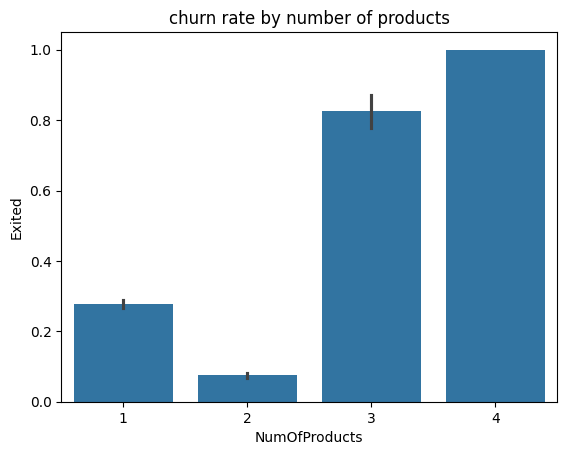

In [23]:
sns.barplot(x="NumOfProducts",y="Exited",data =df)
plt.title('churn rate by number of products')
plt.show()

### Financial Commitment vs Engagement Analysis
#### Balance vs activity cross-analysis
#### Salary–balance mismatch detection
#### Identification of “at-risk premium customers”

In [26]:
high_balance = df['Balance'].quantile(0.75)
print(high_balance)

127644.24


In [29]:
df['highvaluedisengage'] = ((df['Balance']> high_balance) & (df['IsActiveMember'] == 0))

In [30]:
df.groupby('highvaluedisengage')['Exited'].mean()

highvaluedisengage
False    0.189307
True     0.304731
Name: Exited, dtype: float64

### Retention Strength Assessment
#### Define “sticky customer” profiles
#### Measure churn stability across engagement tiers
#### Identify engagement thresholds linked to retention

In [31]:
df['realtionshipscore'] = (
    df['IsActiveMember']*2 + df['NumOfProducts'] + df['HasCrCard']
)

In [33]:
# churn vs score

df.groupby('realtionshipscore')['Exited'].mean()

realtionshipscore
1    0.345404
2    0.304598
3    0.150855
4    0.179517
5    0.077567
6    0.772727
7    1.000000
Name: Exited, dtype: float64

In [34]:
#Credit Card Stickiness Score


df.groupby('HasCrCard')['Exited'].mean()

HasCrCard
0    0.208149
1    0.201843
Name: Exited, dtype: float64